In [6]:
import os
import sys

sys.path.append(os.path.abspath('..'))
import src.data_loader

# Lista todas as funções criadas no arquivo data_loader.py
print(dir(src.data_loader))

['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'gzip', 'os', 'parse_geo_series_matrix', 'pd']


In [8]:
import os
import sys
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.multitest import multipletests

# Adiciona a pasta raiz ao caminho do Python
sys.path.append(os.path.abspath('..'))
from src.data_loader import parse_geo_series_matrix

# Caminho para o arquivo bruto
matrix_file = '../data/raw/GSE68849_series_matrix.txt.gz'

# Processa e carrega os dados
expression_df, metadata_df = parse_geo_series_matrix(matrix_file)

print(f"Matriz de expressão: {expression_df.shape[0]} genes x {expression_df.shape[1]} amostras")
print("\nColunas encontradas nos metadados:")
print(metadata_df.columns.tolist())
print("\nPrimeiras linhas dos metadados:")
display(metadata_df.head(2))


Matriz de expressão: 47321 genes x 10 amostras

Colunas encontradas nos metadados:
['donor', 'agent', 'cell type']

Primeiras linhas dos metadados:


,donor,agent,cell type
sample_id,,,
GSM1684095,donor: Donor 1,agent: No virus control,cell type: Primary human pDCs
GSM1684096,donor: Donor 1,agent: Influenza A,cell type: Primary human pDCs


In [13]:
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.multitest import multipletests

# 1. Padroniza e limpa os textos da coluna 'agent' (remove espaços extras e coloca em minúsculo)
agent_clean = metadata_df['agent'].astype(str).str.strip().str.lower()

# Cria as máscaras booleanas usando busca por palavra-chave
is_control = agent_clean.str.contains('no virus|control').values
is_influenza = agent_clean.str.contains('influenza').values

print(f"Amostras Controle identificadas: {is_control.sum()}")
print(f"Amostras Influenza identificadas: {is_influenza.sum()}")

# 2. Extrai as matrizes numéricas correspondentes
X_ctrl = expression_df.iloc[:, is_control].values.astype(float)
X_flu = expression_df.iloc[:, is_influenza].values.astype(float)

# Aplica transformação log2 caso os dados estejam brutos em escala linear
if np.nanmax(expression_df.values) > 50:
    print("Dados em escala linear detectados. Aplicando transformação Log2...")
    X_ctrl = np.log2(X_ctrl + 1)
    X_flu = np.log2(X_flu + 1)

# 3. Calcula médias e Log2 Fold Change
mean_ctrl = np.nanmean(X_ctrl, axis=1)
mean_flu = np.nanmean(X_flu, axis=1)
log2_fc = mean_flu - mean_ctrl

# 4. Teste t de Welch gene a gene
p_vals = []
for i in range(len(expression_df)):
    c = X_ctrl[i, ~np.isnan(X_ctrl[i, :])]
    f = X_flu[i, ~np.isnan(X_flu[i, :])]
    
    if len(c) >= 2 and len(f) >= 2 and (np.var(c) > 0 or np.var(f) > 0):
        s, p = stats.ttest_ind(f, c, equal_var=False)
        p_vals.append(p if not np.isnan(p) else 1.0)
    else:
        p_vals.append(1.0)

p_vals = np.array(p_vals)

# Correção FDR (Benjamini-Hochberg)
_, fdr_pvals, _, _ = multipletests(p_vals, method='fdr_bh')

# 5. Tabela Final
deg_results = pd.DataFrame({
    'gene_symbol': expression_df.index,
    'mean_control': mean_ctrl,
    'mean_influenza': mean_flu,
    'log2_fold_change': log2_fc,
    'p_value': p_vals,
    'fdr': fdr_pvals
}).set_index('gene_symbol')

# Classificação (Cutoffs: P-value < 0.05 e |Log2FC| > 1)
deg_results['status'] = 'Not Significant'
deg_results.loc[(deg_results['log2_fold_change'] > 1) & (deg_results['p_value'] < 0.05), 'status'] = 'Up-regulated'
deg_results.loc[(deg_results['log2_fold_change'] < -1) & (deg_results['p_value'] < 0.05), 'status'] = 'Down-regulated'

print("\n--- Resumo da Análise de DEG ---")
print(deg_results['status'].value_counts())
print("\n--- Top 5 Genes Mais Significativos ---")
display(deg_results.sort_values('p_value').head(5))

Amostras Controle identificadas: 5
Amostras Influenza identificadas: 5
Dados em escala linear detectados. Aplicando transformação Log2...

--- Resumo da Análise de DEG ---
status
Not Significant    46854
Up-regulated         267
Down-regulated       200
Name: count, dtype: int64

--- Top 5 Genes Mais Significativos ---


,mean_control,mean_influenza,log2_fold_change,p_value,fdr,status
gene_symbol,,,,,,
"""ILMN_1664595""",6.807449,14.058460,7.251011,1.214370e-12,5.746522e-08,Up-regulated
"""ILMN_1769988""",6.972925,14.355389,7.382464,1.129423e-09,2.519484e-05,Up-regulated
"""ILMN_1675192""",7.110382,14.091097,6.980715,1.795810e-09,2.519484e-05,Up-regulated
"""ILMN_2186745""",6.763968,14.315095,7.551127,2.129696e-09,2.519484e-05,Up-regulated
"""ILMN_1752526""",7.674952,11.030347,3.355395,8.834436e-09,8.361087e-05,Up-regulated


✅ Tabela de DEG salva com sucesso em: ../results/deg_results.csv


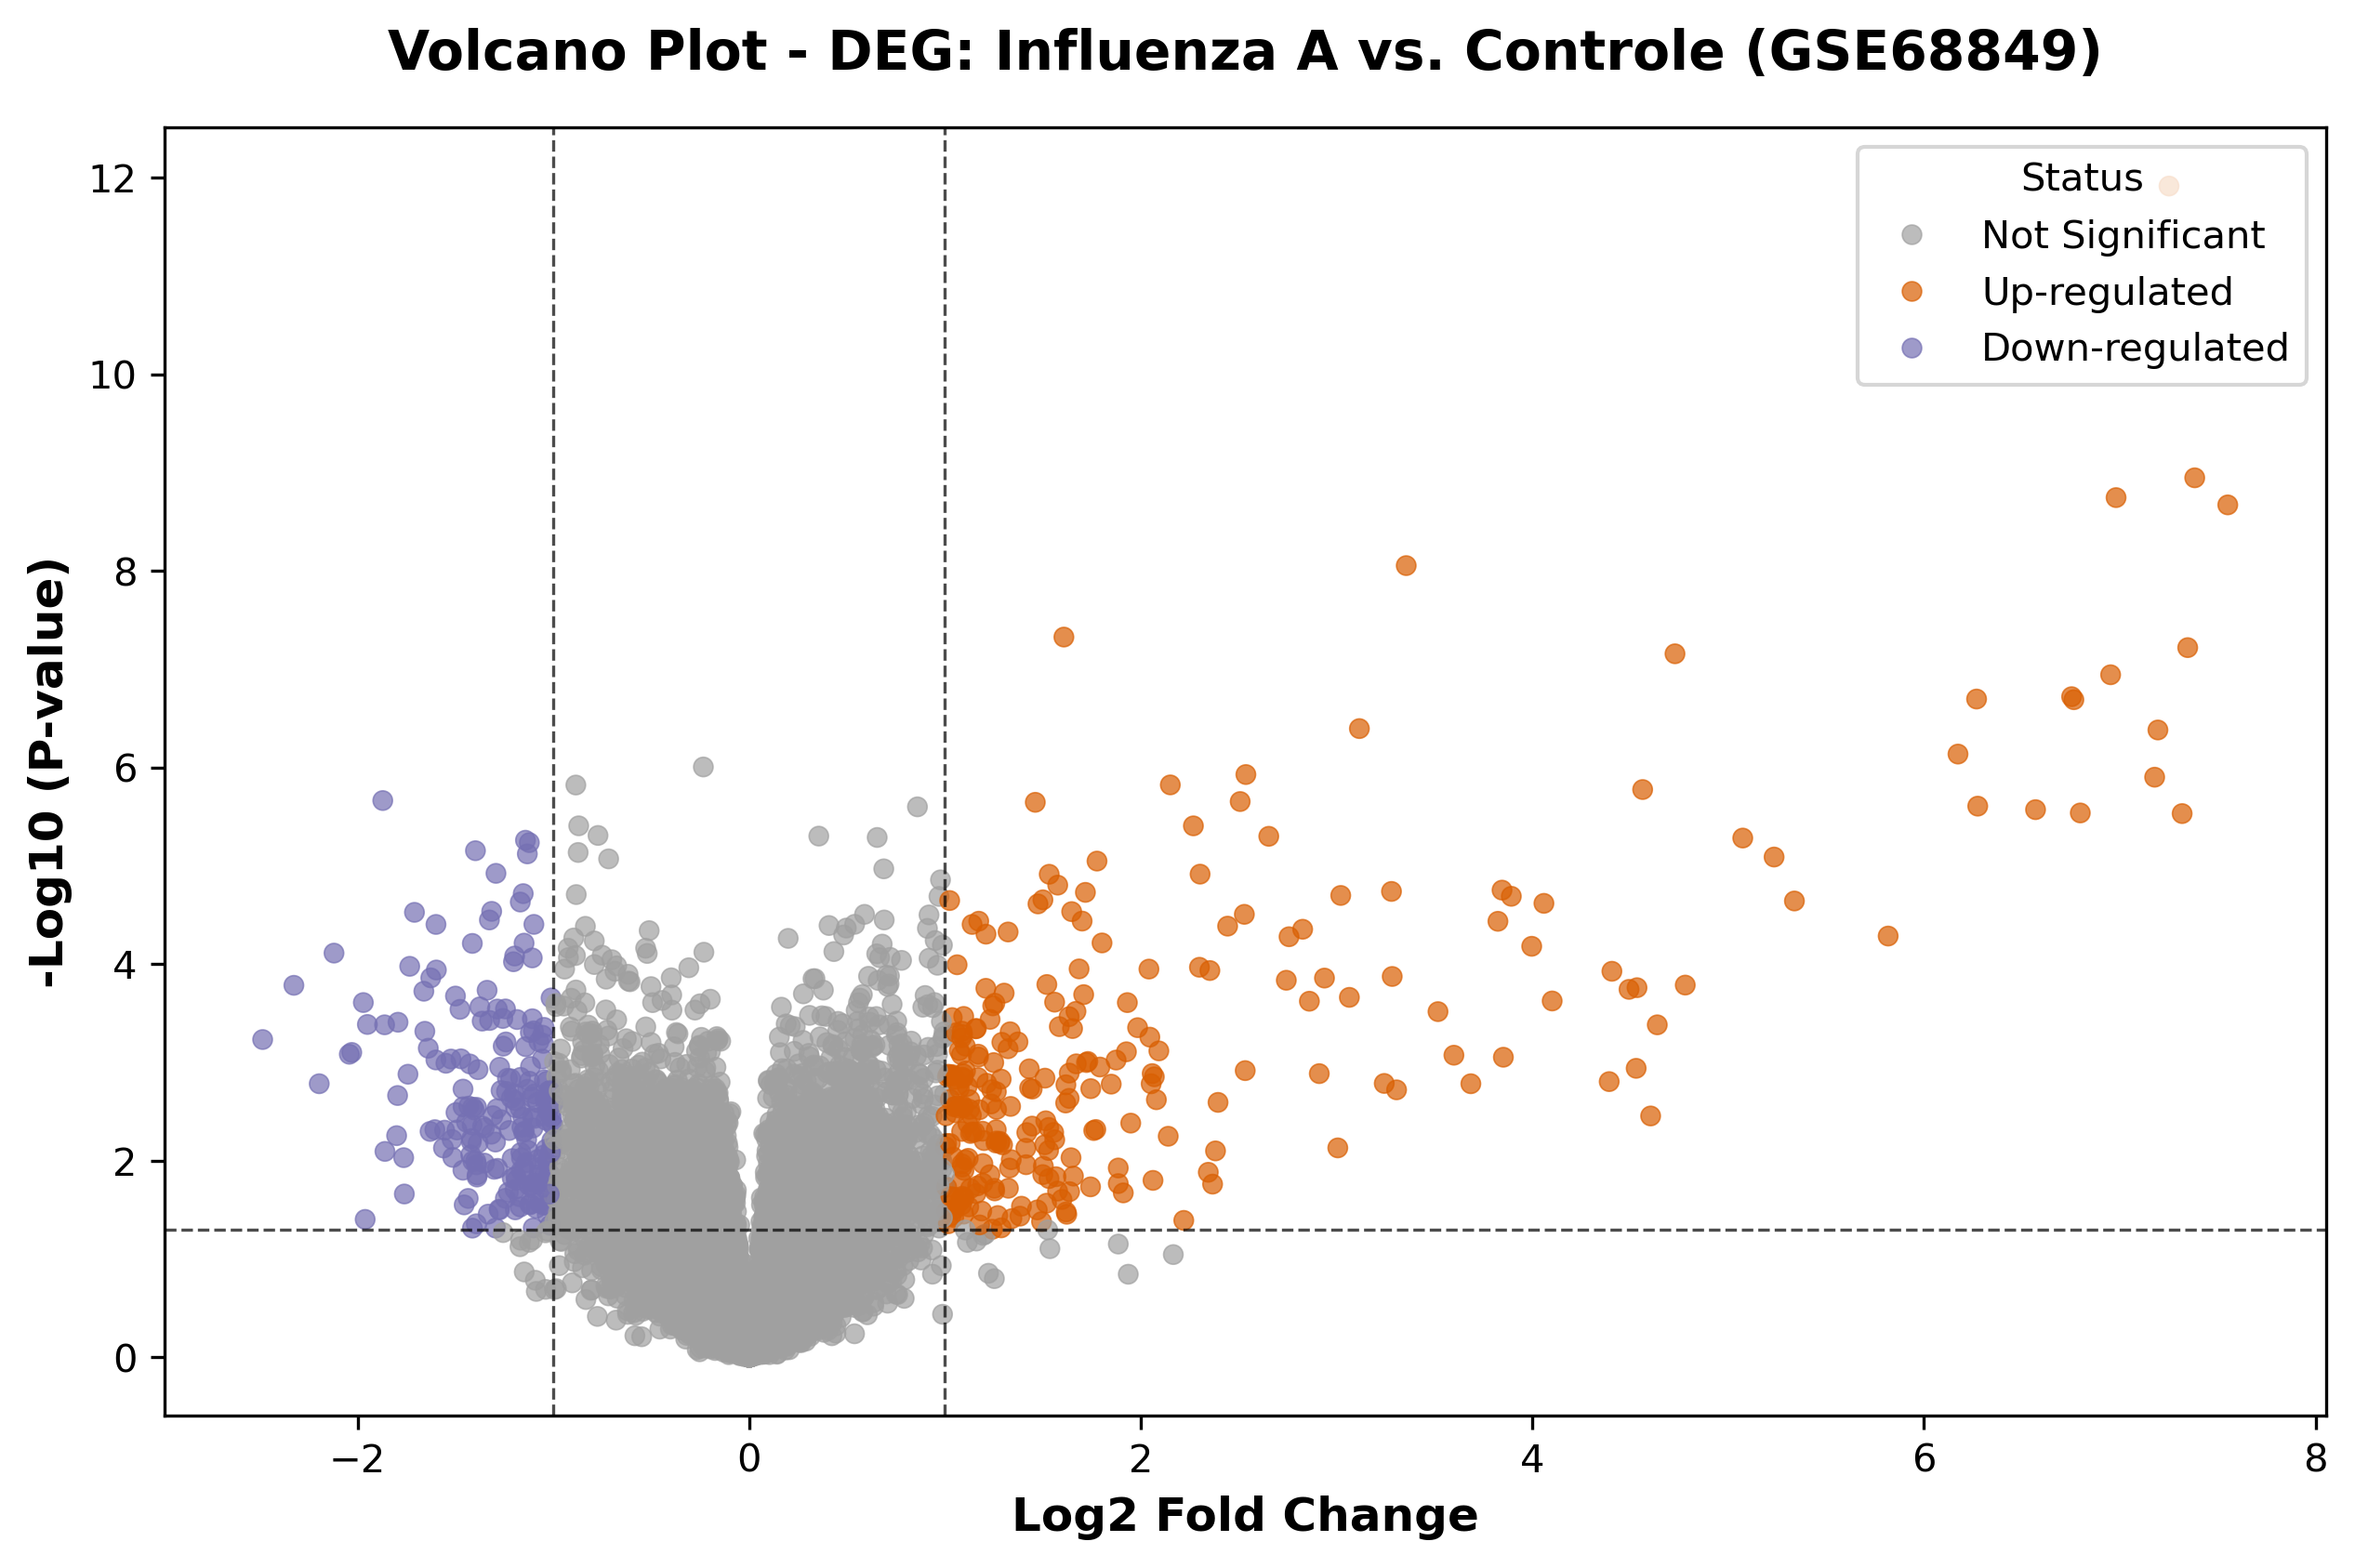

✅ Volcano Plot salvo em: ../results/volcano_plot.png


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Salvar os resultados em CSV
output_path = '../results/deg_results.csv'
os.makedirs('../results', exist_ok=True)
deg_results.to_csv(output_path)
print(f"✅ Tabela de DEG salva com sucesso em: {output_path}")

# 2. Configuração visual do Volcano Plot
plt.figure(figsize=(10, 6), dpi=300)

# -log10(p-value)
deg_results['neg_log10_pval'] = -np.log10(deg_results['p_value'])

# Paleta de cores personalizada
colors = {'Not Significant': '#a0a0a0', 'Up-regulated': '#d95f02', 'Down-regulated': '#7570b3'}

# Plot dos pontos
sns.scatterplot(
    data=deg_results,
    x='log2_fold_change',
    y='neg_log10_pval',
    hue='status',
    palette=colors,
    alpha=0.7,
    s=25,
    edgecolor=None
)

# Linhas de corte (Cutoffs)
plt.axvline(x=1, color='black', linestyle='--', linewidth=0.8, alpha=0.7)
plt.axvline(x=-1, color='black', linestyle='--', linewidth=0.8, alpha=0.7)
plt.axhline(y=-np.log10(0.05), color='black', linestyle='--', linewidth=0.8, alpha=0.7)

# Títulos e rótulos
plt.title('Volcano Plot - DEG: Influenza A vs. Controle (GSE68849)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Log2 Fold Change', fontsize=12, fontweight='bold')
plt.ylabel('-Log10 (P-value)', fontsize=12, fontweight='bold')
plt.legend(title='Status', loc='upper right', frameon=True)

# Salvar figura em alta resolução
fig_path = '../results/volcano_plot.png'
plt.savefig(fig_path, bbox_inches='tight')
plt.show()

print(f"✅ Volcano Plot salvo em: {fig_path}")